In [65]:
import pandas as pd
import numpy as np

In [67]:
full_df = pd.read_csv("players_22.csv", low_memory=False)

In [93]:
#Feature Selection
df = full_df[['short_name','pace','shooting', 'passing', 'dribbling', 'defending', 'physic', 'skill_moves']].copy()

In [94]:
df.sample()

,short_name,pace,shooting,passing,dribbling,defending,physic,skill_moves
1241,M. Borjan,NaN,NaN,NaN,NaN,NaN,NaN,1


In [95]:
X = df.iloc[:,1:]

In [81]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

In [92]:
#Preprocessing data
imputer = SimpleImputer(strategy='median')
X_imputed = imputer.fit_transform(X)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)

# PCA Projection
# Reducing to 2 components for 2D visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Critical Logic Check: Explained Variance
print(f"Information retained: {pca.explained_variance_ratio_.sum() * 100:.2f}%")
print(X_pca)

Information retained: 69.78%
[[ 6.45985023  0.50835122]
 [ 4.9564028   1.65657248]
 [ 6.11646963  0.57448302]
 ...
 [-2.20044163 -1.8039996 ]
 [-1.75690916 -4.0958953 ]
 [-1.8916815  -2.47839383]]


In [97]:
#Elbow Method for finding optimal number of clusters
cent = []
for k in range(1,15):
    km = KMeans(n_clusters = k, random_state = 42)
    km.fit(X_pca)
    cent.append(km.inertia_)
print(cent)

[93970.56698521161, 55370.322301501306, 41907.13936206515, 28698.09908839275, 23023.35689668713, 19992.431636272257, 16987.66580155102, 16003.225746156795, 13833.946570388962, 12140.173088186752, 11012.388113761921, 10089.497174209831, 9273.122328032263, 8742.285677648633]


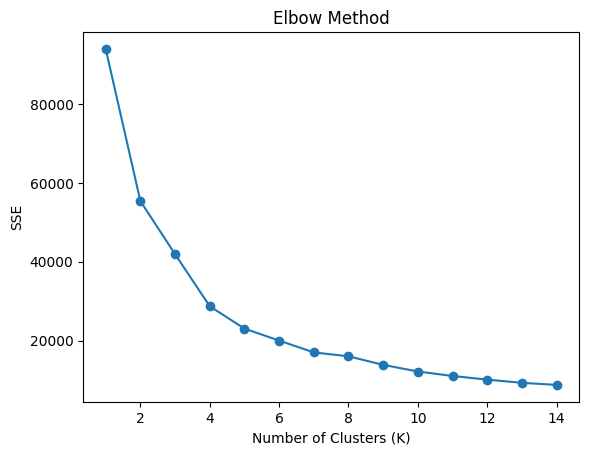

In [98]:
import matplotlib.pyplot as plt
plt.plot(range(1,15), cent, marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("SSE")
plt.title("Elbow Method")
plt.show()

In [99]:
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=4, random_state=42)
cluster_labels = kmeans.fit_predict(X_pca)
df['cluster'] = cluster_labels

In [100]:
df.head(5)

,short_name,pace,shooting,passing,dribbling,defending,physic,skill_moves,cluster
0,L. Messi,85.0,92.0,91.0,95.0,34.0,65.0,4,2
1,R. Lewandowski,78.0,92.0,79.0,86.0,44.0,82.0,4,2
2,Cristiano Ronaldo,87.0,94.0,80.0,88.0,34.0,75.0,5,2
3,Neymar Jr,91.0,83.0,86.0,94.0,37.0,63.0,5,2
4,K. De Bruyne,76.0,86.0,93.0,88.0,64.0,78.0,4,2


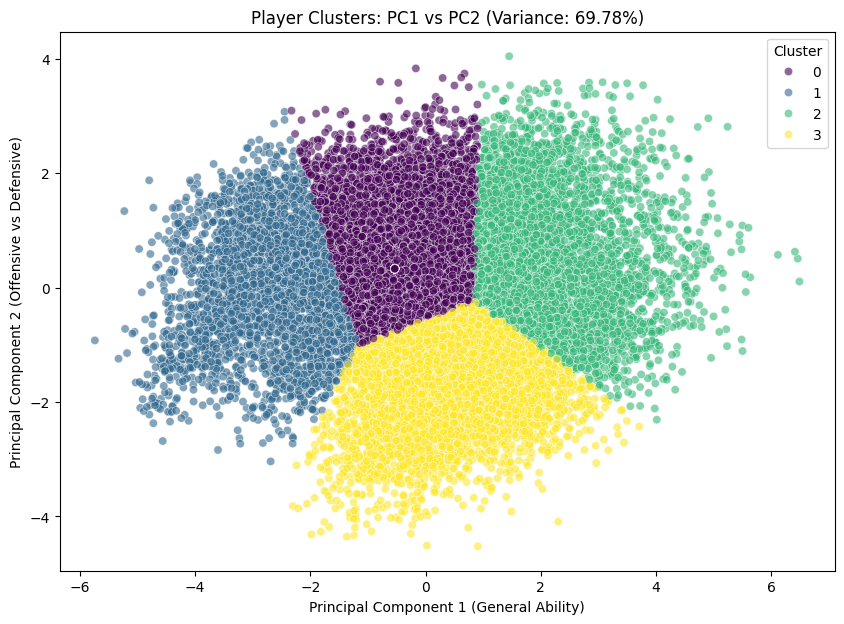

In [101]:
import seaborn as sns
plt.figure(figsize=(10, 7))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=df['cluster'], palette='viridis', alpha=0.6)
plt.title('Player Clusters: PC1 vs PC2 (Variance: 69.78%)')
plt.xlabel('Principal Component 1 (General Ability)')
plt.ylabel('Principal Component 2 (Offensive vs Defensive)')
plt.legend(title='Cluster')
plt.show()

In [102]:
df['player_positions'] = full_df['player_positions']
df['nationality_name'] = full_df['nationality_name']

In [103]:
cluster_insights = df.groupby('cluster').mean(numeric_only=True)
print("\n--- Cluster Stat Profiles ---")
print(cluster_insights)

# Logic: Find the most common position in each cluster
for i in range(4):
    top_pos = df[df['cluster'] == i]['player_positions'].str.split(',').str[0].mode()[0]
    top_nation = df[df['cluster'] == i]['nationality_name'].mode()[0]
    print(f"Cluster {i}: Predominantly {top_pos}s | Most Common Nationality: {top_nation}")


--- Cluster Stat Profiles ---
              pace   shooting    passing  dribbling  defending     physic  \
cluster                                                                     
0        65.344658  48.887667  58.771210  62.101728  61.836606  69.415161   
1        59.081298  32.395054  44.830294  48.466461  60.211747  66.365997   
2        73.841455  65.993164  68.019846  72.678501  52.424035  67.834840   
3        72.600000  57.116137  53.636514  63.044994  32.295406  54.922261   

         skill_moves  
cluster               
0           1.857143  
1           2.008346  
2           3.196031  
3           2.556419  
Cluster 0: Predominantly GKs | Most Common Nationality: England
Cluster 1: Predominantly CBs | Most Common Nationality: England
Cluster 2: Predominantly CMs | Most Common Nationality: Spain
Cluster 3: Predominantly STs | Most Common Nationality: England
